# Online Retail Data Analysis
## Machine Learning Pipeline

**Dataset:** UCI Online Retail II  
**Goal:** Customer Segmentation using RFM Analysis, Clustering & Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(r'D:\University\DEPI 2025-2026\MLOps\ML\Online_retail_UCI\online_retail_II.csv.zip')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Part 1 — Data Exploration
Exploring the dataset to understand its structure, size, and quality issues.

In [2]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


In [4]:
df.shape

(1067371, 8)

In [5]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 117.3 MB


## Part 2 — Data Cleaning
Cleaning the data by removing cancellations, non-product codes, negative values, outliers, and missing customer IDs.

In [7]:
df['is_cancelled']=df['Invoice'].str.startswith('C')
df['is_cancelled'].value_counts()

is_cancelled
False    1047877
True       19494
Name: count, dtype: int64

In [8]:
df_Sales=df[~df['is_cancelled']]
df_Returns=df[df['is_cancelled']]
print('Sales: ',df_Sales.shape)
print('Returns: ',df_Returns.shape)

Sales:  (1047877, 9)
Returns:  (19494, 9)


In [9]:
non_product = ['POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK', 'C2', 'AMAZONFEE']
df_Sales= df_Sales[df_Sales['StockCode'].str.len()>=5]
df_Sales=df_Sales[~df_Sales['StockCode'].isin(non_product)]
df_Sales.shape

(1043305, 9)

In [10]:
df_Sales=df_Sales[df_Sales['Quantity']>0]
df_Sales=df_Sales[df_Sales['Price']>0]
df_Sales.shape

(1037130, 9)

In [11]:
df_Sales=df_Sales[df_Sales['Quantity'].between(df_Sales['Quantity'].quantile(0.01),df_Sales['Quantity'].quantile(0.99))]
df_Sales=df_Sales[df_Sales['Price'].between(df_Sales['Price'].quantile(0.01),df_Sales['Price'].quantile(0.99))]
df_Sales.shape

(1011214, 9)

In [12]:
df_Sales=df_Sales.dropna(subset='Customer ID')
df_Sales.shape

(784140, 9)

In [13]:
df_Sales['Description'] = df_Sales['Description'].fillna('UNKNOWN')

In [14]:
df_Sales['Country'].value_counts()

Country
United Kingdom          709323
Germany                  15782
EIRE                     14802
France                   13072
Netherlands               3869
Spain                     3535
Switzerland               2905
Belgium                   2886
Portugal                  2364
Channel Islands           1525
Australia                 1507
Italy                     1425
Norway                    1382
Cyprus                    1127
Sweden                    1031
Finland                    969
Austria                    878
Denmark                    702
Greece                     646
Unspecified                518
Poland                     502
Japan                      440
USA                        402
United Arab Emirates       373
Singapore                  323
Israel                     311
Malta                      274
Iceland                    251
Canada                     223
Lithuania                  188
RSA                        122
Brazil                      93


In [15]:
country_freq=df_Sales['Country'].value_counts(normalize=True)
df_Sales['Country']=df_Sales['Country'].replace(country_freq[country_freq<0.01].index,'Other')
df_Sales['Country'].value_counts()

Country
United Kingdom    709323
Other              31161
Germany            15782
EIRE               14802
France             13072
Name: count, dtype: int64

## Part 3 — Feature Engineering (RFM)
Building RFM features: Recency, Frequency, and Monetary value per customer.

In [16]:
df_Sales['Revenue']=df_Sales['Quantity']*df_Sales['Price']

In [17]:
from datetime import timedelta
snapshot_date = df_Sales['InvoiceDate'].max() + timedelta(days=1)
print(snapshot_date)

rfm=df_Sales.groupby('Customer ID').agg(Recency=('InvoiceDate', lambda x:(snapshot_date-x.max()).days),
                                        Frequency=('Invoice', 'nunique'),
                                        Monetary=('Revenue', 'sum')).reset_index()
rfm.head()

2011-12-10 12:50:00


,Customer ID,Recency,Frequency,Monetary
0,12346.0,529,11,372.86
1,12347.0,2,8,5377.72
2,12348.0,75,5,1056.24
3,12349.0,19,3,3498.94
4,12350.0,310,1,294.40


In [18]:
rfm['F_score'] = pd.qcut(rfm['Frequency'], q=5, labels=False, duplicates='drop') + 1
rfm[['Customer ID', 'Frequency', 'F_score']].head(10)

,Customer ID,Frequency,F_score
0,12346.0,11,4
1,12347.0,8,3
2,12348.0,5,3
3,12349.0,3,2
4,12350.0,1,1
5,12351.0,1,1
6,12352.0,9,4
7,12353.0,2,1
8,12354.0,1,1
9,12355.0,2,1


In [19]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=False, duplicates='drop') + 1
rfm[['Customer ID', 'Monetary', 'M_score']].head(10)

,Customer ID,Monetary,M_score
0,12346.0,372.86,2
1,12347.0,5377.72,5
2,12348.0,1056.24,3
3,12349.0,3498.94,5
4,12350.0,294.40,2
5,12351.0,300.93,2
6,12352.0,1729.54,4
7,12353.0,406.76,2
8,12354.0,1079.40,3
9,12355.0,947.61,3


In [20]:
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=False, duplicates='drop')
rfm['R_score'] = 5 - rfm['R_score']
rfm[['Customer ID', 'Recency', 'R_score']].head(10)

,Customer ID,Recency,R_score
0,12346.0,529,1
1,12347.0,2,5
2,12348.0,75,3
3,12349.0,19,5
4,12350.0,310,2
5,12351.0,375,2
6,12352.0,36,4
7,12353.0,204,2
8,12354.0,232,2
9,12355.0,214,2


In [21]:
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm[['Customer ID', 'R_score', 'F_score', 'M_score', 'RFM_total']].head(10)

,Customer ID,R_score,F_score,M_score,RFM_total
0,12346.0,1,4,2,7
1,12347.0,5,3,5,13
2,12348.0,3,3,3,9
3,12349.0,5,2,5,12
4,12350.0,2,1,2,5
5,12351.0,2,1,2,5
6,12352.0,4,4,4,12
7,12353.0,2,1,2,5
8,12354.0,2,1,3,6
9,12355.0,2,1,3,6


In [22]:
def rfm_label(row):
    if row['RFM_total'] >= 13: return 'Champions'
    elif row['R_score'] >= 4: return 'Loyal'
    elif row['R_score'] >= 3: return 'Potential Loyalist'
    elif row['R_score'] == 2: return 'At Risk'
    else: return 'Lost'

rfm['RFM_segment'] = rfm.apply(rfm_label, axis=1)

rfm['RFM_segment'].value_counts()

RFM_segment
Loyal                 1492
Lost                  1160
At Risk               1155
Potential Loyalist    1143
Champions              847
Name: count, dtype: int64

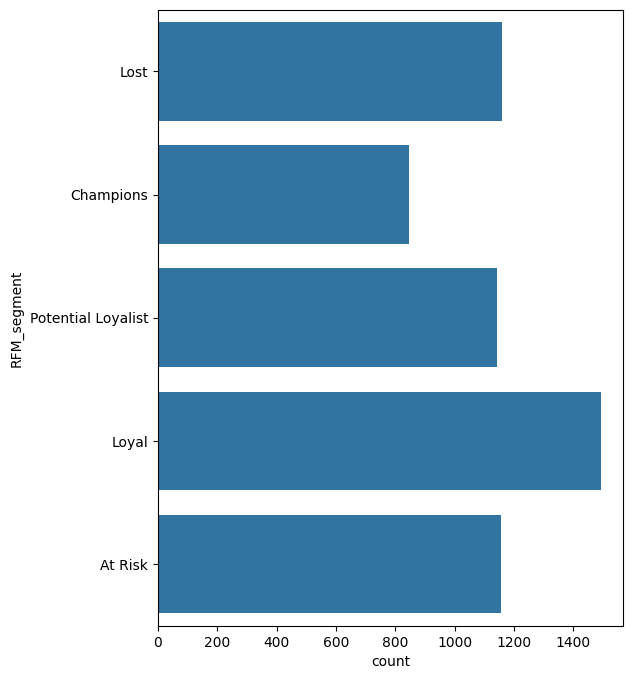

In [23]:
plt.figure(figsize=(6,8))
sns.countplot(rfm['RFM_segment'])
plt.show()

## Part 4 — Clustering (K-Means)
Segmenting customers into groups using K-Means clustering.

In [24]:
from sklearn.preprocessing import RobustScaler
scale=RobustScaler()
X=rfm[['F_score','R_score','M_score']]
x_scale=scale.fit_transform(X)

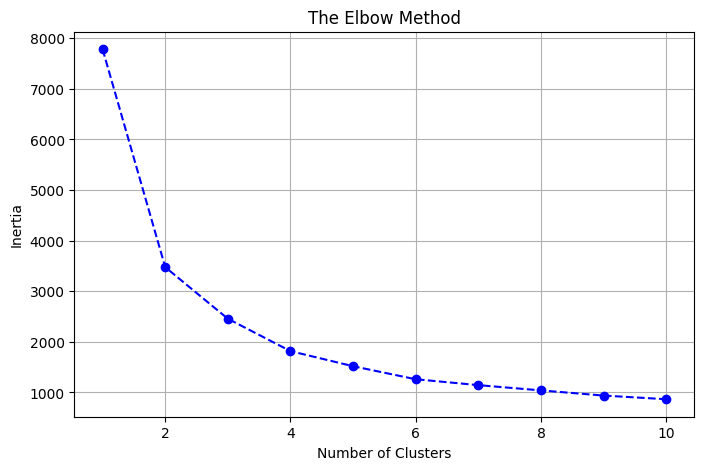

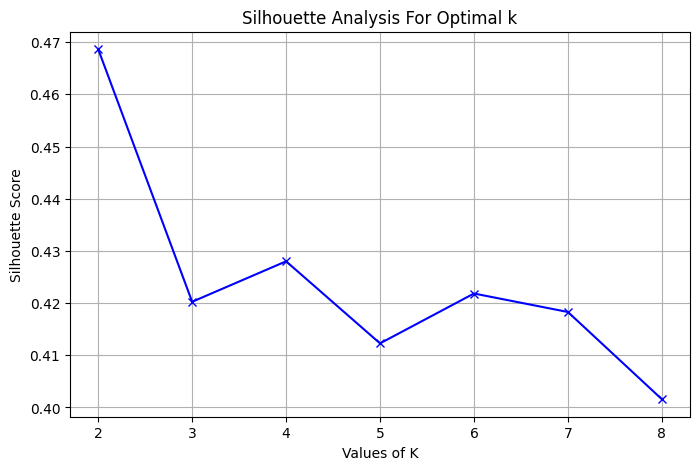

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = x_scale

inertias = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_) 
    
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o', linestyle='--', color='blue')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)

#Silhouette Analysis 
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_
    
    score = silhouette_score(X, cluster_labels)
    silhouette_avg.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Values of K') 
plt.ylabel('Silhouette Score') 
plt.title('Silhouette Analysis For Optimal k')
plt.grid(True)
plt.show()

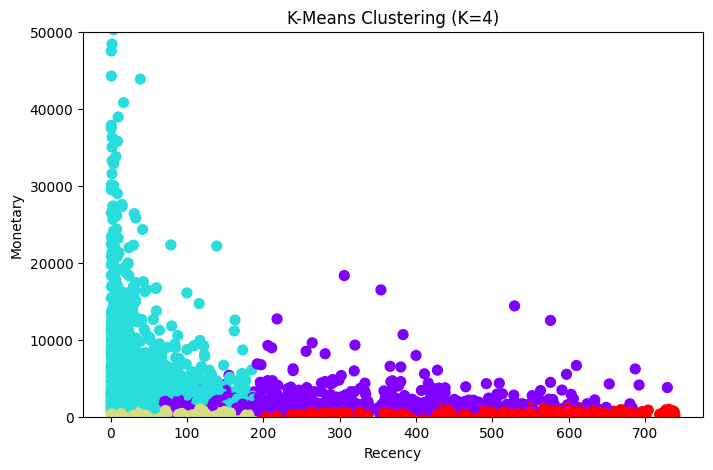

In [26]:
Kmeans= KMeans (n_clusters=4, random_state=42, n_init=10)
rfm['Cluster']=Kmeans.fit_predict(x_scale)

plt.figure(figsize=(8, 5))
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='rainbow', s=50)
plt.title('K-Means Clustering (K=4)')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.ylim(0, 50000)
plt.show()

## Part 5 — Supervised Learning (Classification)
Predicting whether a customer is high-value using Random Forest with hyperparameter tuning.

In [27]:
threshold=rfm['Monetary'].quantile(0.75)
rfm['high']=(rfm['Monetary']>=threshold).astype(int)
rfm['high'].value_counts()

high
0    4347
1    1450
Name: count, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = rfm[['Recency', 'Frequency', 'R_score', 'F_score', 'M_score', 'RFM_total']]
y = rfm['high']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model= RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_predict= model.predict(X_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       879
           1       0.86      0.86      0.86       281

    accuracy                           0.93      1160
   macro avg       0.91      0.91      0.91      1160
weighted avg       0.93      0.93      0.93      1160



In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


In [30]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       879
           1       0.95      0.84      0.89       281

    accuracy                           0.95      1160
   macro avg       0.95      0.91      0.93      1160
weighted avg       0.95      0.95      0.95      1160



## Deployment
Saving the trained model for use in the Streamlit app.

In [31]:
import joblib
joblib.dump(best_model, 'model.pkl')

['model.pkl']